<a href="https://colab.research.google.com/github/DhanaSekhar-0-1/machine_learning/blob/main/LinerReg_P2_Ridge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===============================
# 0. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# ===============================
# 1. LOAD DATASET
# ===============================
df = pd.read_csv('/content/house_prices_practice.csv')

print(df.head())

   Id  OverallQual  GrLivArea  GarageCars  TotalBsmtSF  YearBuilt  FullBath  \
0   1            7       1560           0         1658       1969         2   
1   2            4       2827           2         1319       2012         3   
2   3            8       3920           0          841       2010         1   
3   4            5       3044           0         1058       1998         0   
4   5            7        801           1         2428       2020         0   

   BedroomAbvGr  LotArea  SalePrice  
0             1     8059     177106  
1             4    13530     301044  
2             4     9010     360609  
3             4    13207     240556  
4             1     9117     193656  


In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB
None
               Id  OverallQual    GrLivArea  GarageCars  TotalBsmtSF  \
count  300.000000   300.000000   300.000000  300.000000   300.000000   
mean   150.500000     5.326667  2307.386667    1.330000  1468.796667   
std     86.746758     2.873001  1042.561303    1.109898   672.333705   
min      1.000000     1.000000   504.000000    0.000000   303.000000  

In [ ]:
# ===============================
# 2. DATA CLEANING
# ===============================
df = df.drop('Id', axis=1)

In [ ]:
# ===============================
# 3. FEATURES & TARGET
# ===============================
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [ ]:
# ===============================
# 4. TRAIN–TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# ===============================
# 5. MULTIPLE LINEAR REGRESSION
# ===============================
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

In [ ]:
# ===============================
# 6. LINEAR REGRESSION EVALUATION
# ===============================
print("\n=== Multiple Linear Regression ===")
print("MAE :", mean_absolute_error(y_test, y_pred_linear))
print("MSE :", mean_squared_error(y_test, y_pred_linear))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_linear)))
print("R²  :", r2_score(y_test, y_pred_linear))

print("\nOverfitting Check (Linear)")
print("Train R²:", linear_model.score(X_train, y_train))
print("Test  R²:", linear_model.score(X_test, y_test))



=== Multiple Linear Regression ===
MAE : 10431.655979707499
MSE : 156386511.419058
RMSE: 12505.459264619512
R²  : 0.9724369952260797

Overfitting Check (Linear)
Train R²: 0.97903560732947
Test  R²: 0.9724369952260797


In [ ]:
# ===============================
# 7. LINEAR REGRESSION COEFFICIENTS
# ===============================
linear_coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear Coefficient': linear_model.coef_
}).sort_values(by='Linear Coefficient', ascending=False)

print("\nLinear Regression Coefficients:")
print(linear_coef_df)

print("\nLinear Intercept:", linear_model.intercept_)


Linear Regression Coefficients:
        Feature  Linear Coefficient
2    GarageCars        19109.641614
0   OverallQual        11914.688135
5      FullBath        11040.343046
6  BedroomAbvGr         4812.061994
4     YearBuilt          746.370978
1     GrLivArea           55.410257
3   TotalBsmtSF           25.199018
7       LotArea           -0.159522

Linear Intercept: -1512820.5684315367


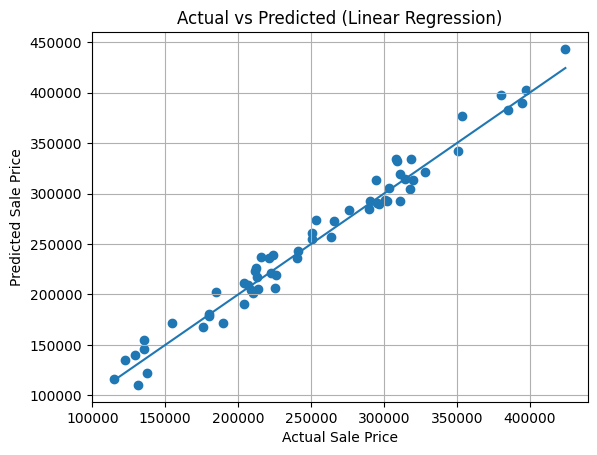

In [ ]:
# ===============================
# 8. ACTUAL vs PREDICTED (LINEAR)
# ===============================
plt.figure()
plt.scatter(y_test, y_pred_linear)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted (Linear Regression)")
plt.grid(True)
plt.show()

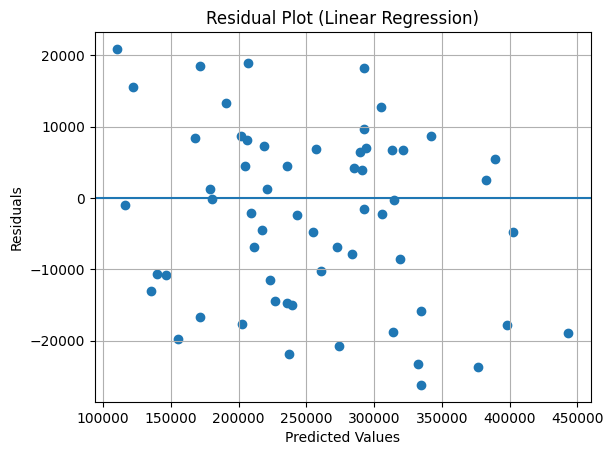

In [ ]:
# ===============================
# 9. RESIDUAL PLOT (LINEAR)
# ===============================
residuals_linear = y_test - y_pred_linear

plt.figure()
plt.scatter(y_pred_linear, residuals_linear)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Linear Regression)")
plt.grid(True)
plt.show()

In [ ]:
# =====================================================
# 10. FEATURE SCALING (REQUIRED FOR RIDGE)
# =====================================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# ===============================
# 11. RIDGE REGRESSION
# ===============================
ridge_model = Ridge(alpha=1.0)   # λ = 1.0
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

In [ ]:
# ===============================
# 12. RIDGE REGRESSION EVALUATION
# ===============================
print("\n=== Ridge Regression ===")
print("MAE :", mean_absolute_error(y_test, y_pred_ridge))
print("MSE :", mean_squared_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R²  :", r2_score(y_test, y_pred_ridge))

print("\nOverfitting Check (Ridge)")
print("Train R²:", ridge_model.score(X_train_scaled, y_train))
print("Test  R²:", ridge_model.score(X_test_scaled, y_test))


=== Ridge Regression ===
MAE : 10409.678222667757
MSE : 154881975.2778271
RMSE: 12445.15870842261
R²  : 0.9727021685870492

Overfitting Check (Ridge)
Train R²: 0.9790171879057566
Test  R²: 0.9727021685870492


In [ ]:
# ===============================
# 13. RIDGE COEFFICIENTS (SCALED)
# ===============================
ridge_coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Ridge Coefficient': ridge_model.coef_
}).sort_values(by='Ridge Coefficient', ascending=False)

print("\nRidge Regression Coefficients:")
print(ridge_coef_df)


Ridge Regression Coefficients:
        Feature  Ridge Coefficient
1     GrLivArea       56802.078228
0   OverallQual       33026.293138
2    GarageCars       21156.377348
3   TotalBsmtSF       16594.391408
4     YearBuilt       15815.971047
5      FullBath       12513.717799
6  BedroomAbvGr        6879.467253
7       LotArea        -612.623174


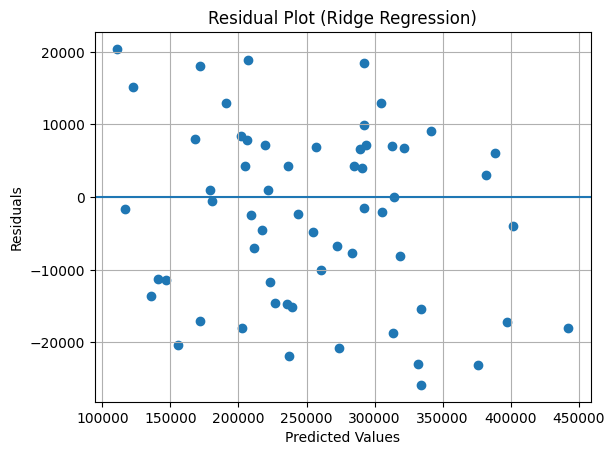

In [ ]:
# ===============================
# 14. RESIDUAL PLOT (RIDGE)
# ===============================
ridge_residuals = y_test - y_pred_ridge

plt.figure()
plt.scatter(y_pred_ridge, ridge_residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Ridge Regression)")
plt.grid(True)
plt.show()

In [ ]:
# ===============================
# 15. NEW HOUSE PREDICTION (RIDGE)
# ===============================
new_house = pd.DataFrame({
    'OverallQual': [7],
    'GrLivArea': [2500],
    'GarageCars': [2],
    'TotalBsmtSF': [1500],
    'YearBuilt': [2015],
    'FullBath': [2],
    'BedroomAbvGr': [3],
    'LotArea': [9000]
})

# Ensure column order matches training data
new_house = new_house[X.columns]

new_house_scaled = scaler.transform(new_house)
ridge_price = ridge_model.predict(new_house_scaled)

print("\nPredicted House Price (Ridge):", ridge_price[0])



Predicted House Price (Ridge): 323872.92899681046
